# Exploratory data analysis (EDA) of apartments data

## Libraries and settings

In [1]:
# Libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pylab as py

# seaborn graphics settings
sns.set(color_codes=True)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Show current working directory
print(os.getcwd())

/workspaces/data_analytics/Week_04


## Univariate non-graphical exploratory data analysis (EDA)

### Importing the enriched apartment data

In [2]:
# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched.csv")[['web-scraper-order',
                                                        'address_raw',
                                                        'lat',
                                                        'lon',
                                                        'bfs_number',
                                                        'bfs_name',
                                                        'rooms', 
                                                        'area', 
                                                        'luxurious', 
                                                        'price', 
                                                        'price_per_m2',
                                                        'pop',
                                                        'pop_dens',
                                                        'emp',
                                                        'frg_pct',
                                                        'mean_taxable_income']]

# Remove duplicates
df_orig = df_orig.drop_duplicates()
df_orig.head(5)

# Remove missing values
df_orig = df_orig.dropna()
df_orig.head(5)

,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop,pop_dens,emp,frg_pct,mean_taxable_income
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49.0,0,1441.0,29.41,12286,1221.272366,5053.0,24.841283,65362.042683
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111.0,0,2600.0,23.42,12286,1221.272366,5053.0,24.841283,65362.042683
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58.0,0,1490.0,25.69,12286,1221.272366,5053.0,24.841283,65362.042683
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",47.259834,8.851705,118,Rüti (ZH),4.0,118.0,0,3240.0,27.46,12286,1221.272366,5053.0,24.841283,65362.042683
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",47.266113,8.866872,118,Rüti (ZH),3.0,66.0,0,1450.0,21.97,12286,1221.272366,5053.0,24.841283,65362.042683


### Quantiles original values

In [3]:
df_orig[['price','rooms', 'area', 'price_per_m2', 'pop_dens']].quantile(q=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).round(2)

,price,rooms,area,price_per_m2,pop_dens
0.05,1337.00,1.00,26.00,17.90,336.03
0.10,1492.50,1.50,41.50,20.02,525.66
0.25,1842.25,2.50,63.00,23.30,1044.63
0.50,2391.00,3.50,86.00,27.95,1662.60
0.75,3056.75,4.50,108.75,38.12,4778.99
0.90,3960.00,4.75,140.50,52.78,4778.99
0.95,4957.50,5.50,163.75,67.33,4778.99


### Filter apartments

In [33]:
# OUTLIER ANALYSIS

# 1. Summary Statistics MIT Outliers
print("=" * 70)
print("SUMMARY STATISTICS MIT OUTLIERS")
print("=" * 70)
print(df_orig[['price', 'rooms', 'area', 'price_per_m2']].describe().round(2))
print(f"\nAnzahl Datensätze: {len(df_orig)}")

# 2. Filter ohne Outliers anwenden
df = df_orig.loc[
    (df_orig['area'] >= 20) &           # Min. 20m²
    (df_orig['area'] <= 250) &          # Max. 250m²
    (df_orig['price'] >= 500) &         # Min. 500 CHF
    (df_orig['price'] <= 10000) &       # Max. 10'000 CHF
    (df_orig['price_per_m2'] >= 15) &   # Min. 15 CHF/m²
    (df_orig['price_per_m2'] <= 80) &   # Max. 80 CHF/m²
    (df_orig['rooms'] <= 7) &           # Max. 7 Zimmer
    (df_orig['pop_dens'] <= 5000)       # Population density Filter
]

# 3. Summary Statistics OHNE Outliers
print("\n" + "=" * 70)
print("SUMMARY STATISTICS OHNE OUTLIERS")
print("=" * 70)
print(df[['price', 'rooms', 'area', 'price_per_m2']].describe().round(2))
print(f"\nAnzahl Datensätze: {len(df)}")
print(f"Entfernte Outliers: {len(df_orig) - len(df)} ({((len(df_orig) - len(df)) / len(df_orig) * 100):.1f}%)")

SUMMARY STATISTICS MIT OUTLIERS
         price   rooms     area  price_per_m2
count   786.00  786.00   786.00        786.00
mean   2649.34    3.42    92.43         33.34
std    1289.07    1.30    75.79         17.14
min      10.00    1.00     8.00          0.04
25%    1842.25    2.50    63.00         23.30
50%    2391.00    3.50    86.00         27.95
75%    3056.75    4.50   108.75         38.12
max    9950.00    8.50  1633.00        149.90

Anzahl Datensätze: 786

SUMMARY STATISTICS OHNE OUTLIERS
         price   rooms    area  price_per_m2
count   729.00  729.00  729.00        729.00
mean   2628.71    3.45   89.23         31.34
std    1191.80    1.20   35.11         11.61
min     500.00    1.00   20.00         15.04
25%    1855.00    2.50   65.00         23.39
50%    2395.00    3.50   87.00         27.60
75%    3000.00    4.50  108.00         35.96
max    9950.00    7.00  250.00         79.04

Anzahl Datensätze: 729
Entfernte Outliers: 57 (7.3%)


### Shape (number of rows and colums)

In [34]:
# Number of rows and columns
print(df.shape)

(729, 16)


### Data types

In [35]:
df.dtypes

web-scraper-order       object
address_raw             object
lat                    float64
lon                    float64
bfs_number               int64
bfs_name                object
rooms                  float64
area                   float64
luxurious                int64
price                  float64
price_per_m2           float64
pop                      int64
pop_dens               float64
emp                    float64
frg_pct                float64
mean_taxable_income    float64
dtype: object

### Summary statistics of numeric variables

In [36]:
df.describe()

,lat,lon,bfs_number,rooms,area,luxurious,price,price_per_m2,pop,pop_dens,emp,frg_pct,mean_taxable_income
count,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000
mean,47.407892,8.602423,185.215364,3.451303,89.226337,0.009602,2628.709191,31.341427,154142.090535,2443.729619,168602.074074,27.746271,80351.403353
std,0.085527,0.118923,81.381404,1.196963,35.109007,0.097586,1191.798518,11.607306,183734.290155,1720.838011,220256.959695,7.468401,14348.682063
min,47.195290,8.367652,1.000000,1.000000,20.000000,0.000000,500.000000,15.040000,698.000000,87.959866,129.000000,7.547170,62000.541872
25%,47.360775,8.517454,120.000000,2.500000,65.000000,0.000000,1855.000000,23.390000,8775.000000,1044.628957,3460.000000,24.535004,70964.087938
50%,47.397362,8.564234,230.000000,3.500000,87.000000,0.000000,2395.000000,27.600000,27746.000000,1662.597326,18945.000000,28.032004,80124.204144
75%,47.481819,8.711827,261.000000,4.500000,108.000000,0.000000,3000.000000,35.960000,420217.000000,4778.994655,491193.000000,32.458468,82932.737704
max,47.693893,8.915933,298.000000,7.000000,250.000000,1.000000,9950.000000,79.040000,420217.000000,4778.994655,491193.000000,46.226483,174434.537050


### Statistical measures (min, max, std, mean, median, count) for selected variables

In [37]:
# Price
print('Price:',
      'Count:', round(df.price.count(), 1),
      'Min:', round(df.price.min(), 1),
      'Max:', round(df.price.max(), 1),
      'Mean:', round(df.price.mean(), 1),
      'Median:', round(df.price.median(), 1),
      'Std:', round(df.price.std(), 1))

# Area
print('Area:',
      'Count:', round(df.area.count(), 1),
      'Min:', round(df.area.min(), 1),
      'Max:', round(df.area.max(), 1),
      'Mean:', round(df.area.mean(), 1),
      'Median:', round(df.area.median(), 1),
      'Std:', round(df.area.std(), 1))

Price: Count: 729 Min: 500.0 Max: 9950.0 Mean: 2628.7 Median: 2395.0 Std: 1191.8
Area: Count: 729 Min: 20.0 Max: 250.0 Mean: 89.2 Median: 87.0 Std: 35.1


### Skewness

In [38]:
df[['price','rooms', 'area']].skew()

price    2.318303
rooms    0.059906
area     0.681073
dtype: float64

### Kurtosis

In [39]:
df[['price','rooms', 'area']].kurtosis()

price    8.247800
rooms   -0.115911
area     1.032098
dtype: float64

### Extreme values

In [40]:
# Low costs apartments
df[df['price_per_m2'] <= 10]

,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop,pop_dens,emp,frg_pct,mean_taxable_income


In [41]:
# Very expansive apartments
df[df['price_per_m2'] >= 100]

,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop,pop_dens,emp,frg_pct,mean_taxable_income


### Get a list of categories of categorical variable

In [42]:
np.array(pd.Categorical(df['bfs_name']).categories)

array(['Adliswil', 'Aeugst am Albis', 'Affoltern am Albis', 'Altikon',
       'Andelfingen', 'Bachenbülach', 'Bassersdorf', 'Bauma',
       'Bonstetten', 'Brütten', 'Bülach', 'Dielsdorf', 'Dietikon',
       'Dietlikon', 'Dättlikon', 'Dübendorf', 'Dürnten', 'Egg', 'Eglisau',
       'Elsau', 'Embrach', 'Fehraltorf', 'Feuerthalen',
       'Freienstein-Teufen', 'Fällanden', 'Glattfelden', 'Gossau (ZH)',
       'Greifensee', 'Hausen am Albis', 'Hedingen', 'Hettlingen',
       'Hinwil', 'Hittnau', 'Hochfelden', 'Hombrechtikon', 'Höri',
       'Hüttikon', 'Kloten', 'Knonau', 'Küsnacht (ZH)',
       'Langnau am Albis', 'Laufen-Uhwiesen', 'Lindau', 'Lufingen',
       'Maur', 'Meilen', 'Mettmenstetten', 'Männedorf', 'Mönchaltorf',
       'Neerach', 'Neftenbach', 'Niederglatt', 'Niederhasli',
       'Niederweningen', 'Nürensdorf', 'Oberengstringen', 'Oberglatt',
       'Obfelden', 'Oetwil am See', 'Oetwil an der Limmat', 'Opfikon',
       'Ossingen', 'Pfungen', 'Pfäffikon', 'Regensdorf', 'Rheinau

## Multivariate non-graphical exploratory data analysis (EDA)

### Cross-tabulation

In [43]:
pd.crosstab(df['luxurious'], df['rooms'])

rooms,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0
luxurious,,,,,,,,,,,,,
0,36,26,34,131,44,199,27,161,3,47,1,11,2
1,0,0,0,5,0,2,0,0,0,0,0,0,0


### Pivot tables

In [44]:
# Using pivot_table to reshape the data and calculate means 
pd.pivot_table(df[['rooms', 'price', 'price_per_m2', 'area', 'luxurious']],
               index=['rooms', 'luxurious'],
               values=['price', 'price_per_m2', 'area'],
               aggfunc=(np.mean, 'count'))

area             price              price_per_m2           
                count        mean count         mean        count       mean
rooms luxurious                                                             
1.0   0            36   39.527778    36  1441.444444           36  42.572778
1.5   0            26   39.076923    26  1933.692308           26  52.518846
2.0   0            34   56.735294    34  1926.058824           34  34.855588
2.5   0           131   66.664122   131  2262.458015          131  35.430687
      1             5   71.600000     5  2627.400000            5  36.774000
3.0   0            44   68.159091    44  1964.022727           44  28.677955
3.5   0           199   89.733668   199  2655.256281          199  29.570402
      1             2  102.500000     2  4480.000000            2  43.990000
4.0   0            27   93.222222    27  2828.370370           27  30.204444
4.5   0           161  114.322981   161  3094.602484          161  26.637143
5.0   0             3  108.000000     3  2881.666667            3  26.376667
5.5   0            47  147.617021    47  3603.914894           47  24.387021
6.0   0             1  150.000000     1  4800.000000            1  32.000000
6.5   0            11  167.363636    11  4114.272727           11  24.638182
7.0   0             2  175.000000     2  6350.000000            2  36.325000

### Correlation matrix

In [45]:
corr = df[['rooms', 
          'area', 
          'price', 
          'price_per_m2',
          'pop_dens',
          'frg_pct']].cov().corr()
corr

,rooms,area,price,price_per_m2,pop_dens,frg_pct
rooms,1.000000,0.974745,0.475817,-0.470780,-0.595784,-0.664382
area,0.974745,1.000000,0.660201,-0.261886,-0.401379,-0.480699
price,0.475817,0.660201,1.000000,0.551972,0.422790,0.341089
price_per_m2,-0.470780,-0.261886,0.551972,1.000000,0.988924,0.972002
pop_dens,-0.595784,-0.401379,0.422790,0.988924,1.000000,0.996084
frg_pct,-0.664382,-0.480699,0.341089,0.972002,0.996084,1.000000


### Covariance matrix

In [46]:
cov = df[['rooms', 
          'area', 
          'price', 
          'price_per_m2',
          'pop_dens',
          'frg_pct']].cov()
cov

,rooms,area,price,price_per_m2,pop_dens,frg_pct
rooms,1.432722,34.675185,6.764439e+02,-6.083790,-6.003880e+02,-2.086051
area,34.675185,1232.642382,2.727578e+04,-167.994060,-1.327239e+04,-51.570259
price,676.443923,27275.778824,1.420384e+06,4511.417558,6.128749e+05,1000.853890
price_per_m2,-6.083790,-167.994060,4.511418e+03,134.729541,1.277549e+04,30.459354
pop_dens,-600.387998,-13272.392716,6.128749e+05,12775.491801,2.961283e+06,8302.713281
frg_pct,-2.086051,-51.570259,1.000854e+03,30.459354,8.302713e+03,55.777011


## Univariate graphical exploratory data analysis (EDA)

### Line chart (matplotlib)

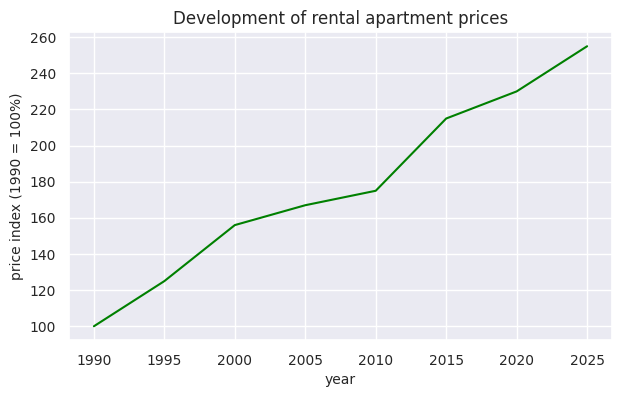

In [47]:
# Generate some useful values (time series)
x = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
y = [100, 125, 156, 167, 175, 215, 230, 255]

# Create figure
fig = plt.figure(figsize=(7,4))
plt.plot(x, y, color="green")
plt.title('Development of rental apartment prices', fontsize=12)
plt.xlabel('year', fontsize=10)
plt.ylabel('price index (1990 = 100%)', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

### Boxplot (seaborn)

<Axes: xlabel='area'>

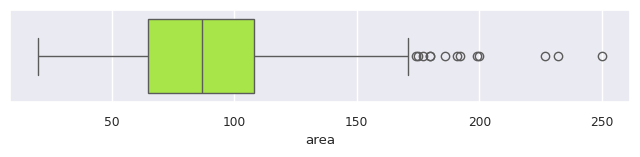

In [48]:
plt.figure(figsize=(8,1.2))
plt.ticklabel_format(style='plain')
sns.boxplot(x=df['area'], color="greenyellow")

### Histogram  (matplotlib)

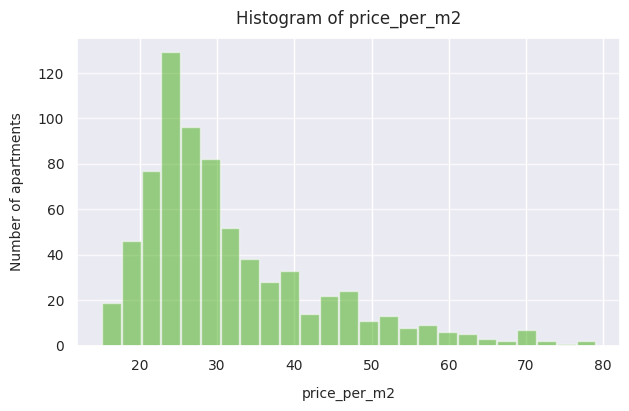

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Plot Histogram
fig = plt.figure( figsize=(7,4))

plt.xticks(fontsize=14, rotation=0)
plt.yticks(fontsize=14, rotation=0)

n, bins, patches = plt.hist(x=df['price_per_m2'], 
                            bins=25, 
                            color='#42AD12',
                            alpha=0.5, 
                            rwidth=0.95
                   )
plt.grid(True)
plt.ticklabel_format(style='plain')
plt.grid(axis='y', alpha=0.75)

# Set labels
plt.xlabel('price_per_m2', fontsize=10, labelpad=10)
plt.ylabel('Number of apartments', fontsize=10, labelpad=10)
plt.title('Histogram of price_per_m2', fontsize=12, pad=10)

# Set fontsize of tick labels
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

### Density plot  (seaborn)

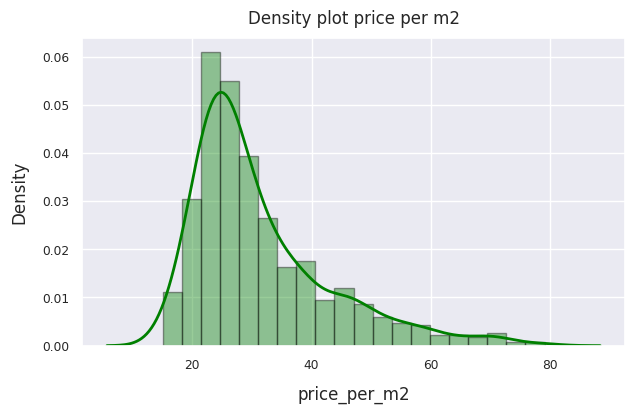

In [50]:
plt.figure(figsize=(7,4))
sns.distplot(df['price_per_m2'], 
             hist=True, 
             kde=True, 
             bins=20, 
             color = 'green',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 2},
            )
plt.title('Density plot price per m2', fontsize=12, pad=10)
plt.xlabel('price_per_m2', fontsize=12, labelpad=10)
plt.ylabel('Density', fontsize=12, labelpad=10)
plt.grid(True)
plt.show()

### Quantile-Quantile (QQ-) plot

      area       var
563   20.0 -1.971754
454   20.0 -1.971754
434   22.0 -1.914789
246   22.0 -1.914789
239   22.0 -1.914789
..     ...       ...
552  199.0  3.126652
320  200.0  3.155135
687  227.0  3.924169
401  232.0  4.066582
205  250.0  4.579271

[729 rows x 2 columns]


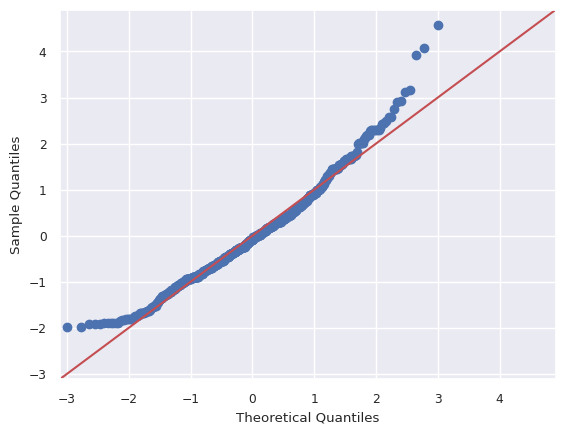

In [51]:
# Variable (standardized)
x = 'area'
df_qq = df
df_qq['var'] = (df[x]-df[x].mean()) / df[x].std()
print(df_qq.sort_values('var')[['area', 'var']])
    
# Plot
sm.qqplot(df_qq['var'], line ='45')
py.show()

### Barchart  (matplotlib)

In [52]:
# Group data by rooms (only the topmost 15 values are shown)
df_bar = df['rooms'].value_counts().nlargest(15).sort_values(ascending=True)

# Values for barchart
napart = list(df_bar.values)
index = list(df_bar.index.values)
index

[6.0, 7.0, 5.0, 6.5, 1.5, 4.0, 2.0, 1.0, 3.0, 5.5, 2.5, 4.5, 3.5]

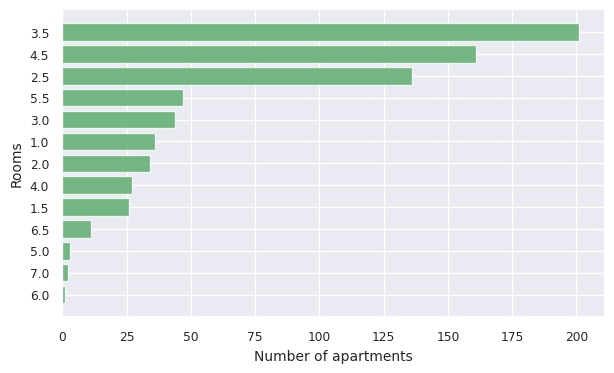

In [53]:
# Group data by rooms (only the topmost 15 values are shown)
df_bar = df['rooms'].value_counts().nlargest(15).sort_values(ascending=True)

# Values for barchart
napart = list(df_bar.values)
index = list(df_bar.index.values)
y_pos = np.arange(len(index))

# Figure
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(y_pos, napart, align='center', color='g', alpha=0.8)
ax.set_yticks(y_pos, index)
ax.set_xlabel('Number of apartments', fontsize=10)
ax.set_ylabel('Rooms', fontsize=10)

# Show graph
plt.show()

### Piechart (matplotlib)

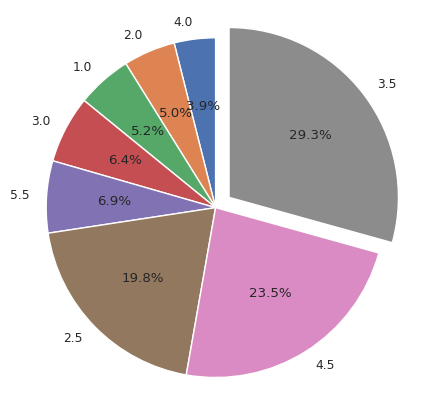

In [54]:
# Group data by rooms (only the 8 most frequently occurencies by rooms)
df_bar = df.rooms.value_counts().nlargest(8).sort_values(ascending=True)

# Simple bar chart
sizes = list(df_bar.values)
labels = list(df_bar.index.values)
explode = (0, 0, 0, 0, 0.0, 0, 0, 0.1) # increases distance of pieces

fig1, ax1 = plt.subplots(figsize=(5,5))
ax1.pie(sizes, 
        labels=labels, 
        explode=explode,
        autopct='%1.1f%%',
        shadow=False, 
        startangle=90)
ax1.axis('equal')  # ensures that pie is drawn as a circle.

plt.show()

## Multivariate graphical exploratory data analysis (EDA)

### Scatterplot (matplotlib)

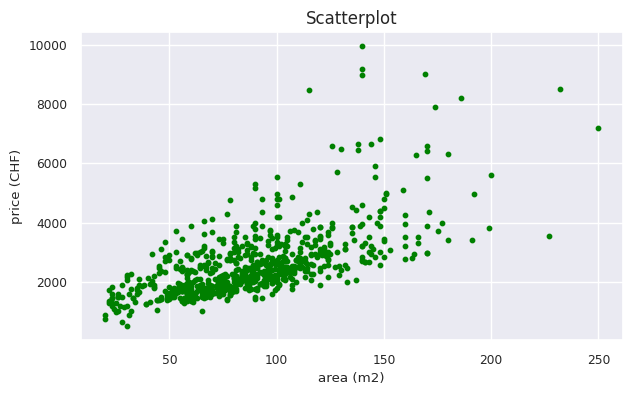

In [55]:
plt.figure(figsize=(7,4))
plt.scatter(df['area'], 
           df['price'], 
           color="green", 
           alpha=1.0,
           s=10)
plt.title('Scatterplot', fontsize=12)
plt.xlabel('area (m2)')
plt.ylabel('price (CHF)')
plt.show()

### Scatterplot (matplotlib) with regression line

(723, 17)
21.934543649804283
675.4046936056707


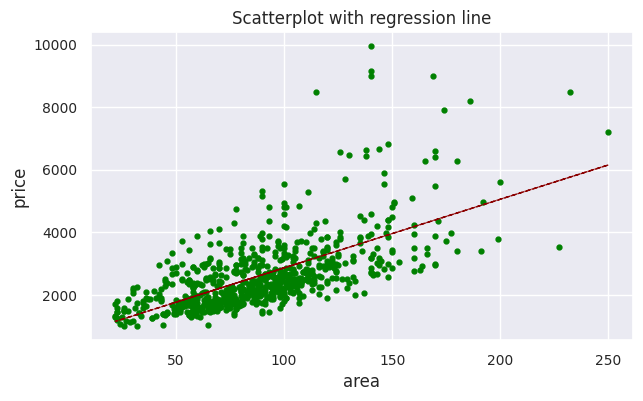

In [56]:
# Subset
df_sub = df.loc[(df.price >= 1000)]
print(df_sub.shape)

# Scatterplot
plt.figure(figsize=(7,4))
plt.plot(df_sub.area, 
         df_sub.price, 
         'o', 
         markersize=3.5,
         color="green")

# Regression line (b = slope, a=intercept)
b, a = np.polyfit(df_sub.area, df_sub.price, 1)
print(b)
print(a)

# Plot regression line
plt.plot(df_sub.area, 
         b*df_sub.area + a, 
         linewidth=1,
         linestyle='dashed',
         color='darkred')

# Add title and axes labels
plt.title('Scatterplot with regression line', fontsize=12)
plt.ylabel('price', fontsize=12)
plt.xlabel('area', fontsize=12)

# Set fontsize of tick labels
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

### Scatterplot-matrix (seaborn)

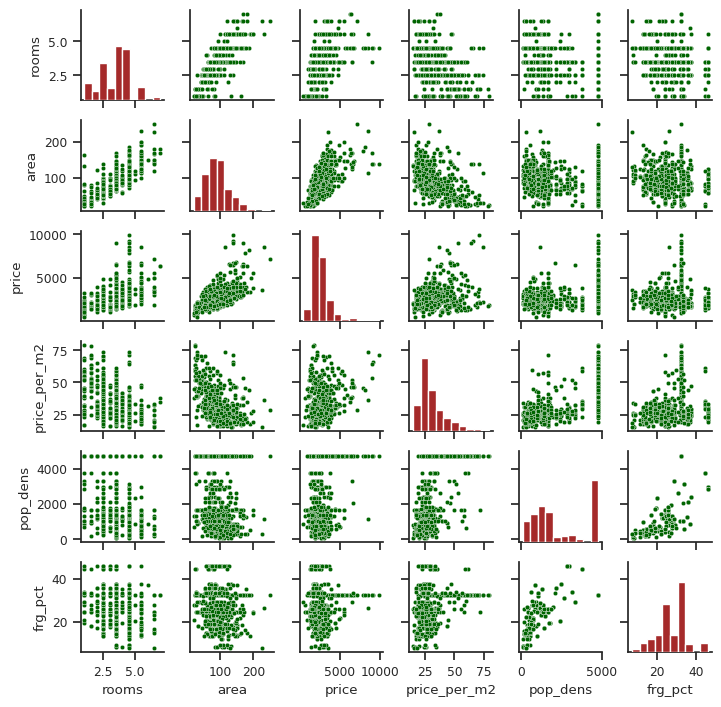

In [57]:
sns.set(style="ticks", font_scale=0.8)
g = sns.PairGrid(df[['rooms', 
                     'area', 
                     'price', 
                     'price_per_m2',
                     'pop_dens',
                     'frg_pct']], 
                 height=1.2, 
                 aspect=1)
g.map_upper(sns.scatterplot,color='darkgreen', s=10)
g.map_lower(sns.scatterplot, color='darkgreen', s=10)
g.map_diag(plt.hist, color='brown')

### Hexagonal binning plot  (matplotlib)

(709, 17)


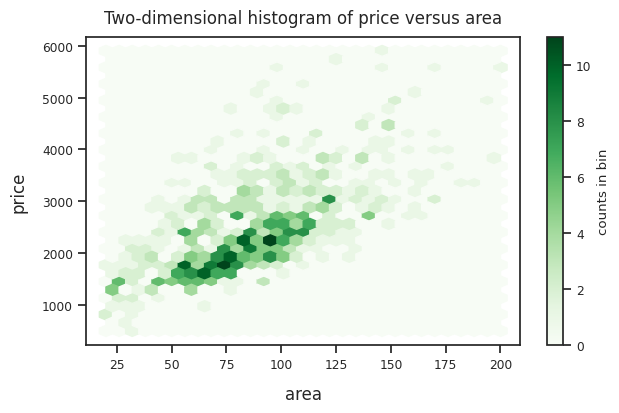

In [58]:
# Subset
df_sub = df.loc[(df.price <= 6000) & (df.area <= 200)]
print(df_sub.shape)

# Plot
fig = plt.figure( figsize=(7,4) )
plt.hexbin(df_sub.area, df_sub.price, gridsize=30, cmap='Greens')

# Set labels
plt.xlabel('area', fontsize=12, labelpad=10)
plt.ylabel('price', fontsize=12, labelpad=10)
plt.title('Two-dimensional histogram of price versus area', fontsize=12, pad=10)

cb = plt.colorbar(label='count in bin')
cb.set_label('counts in bin')

### Correlation heatmap (seaborn)

<Axes: >

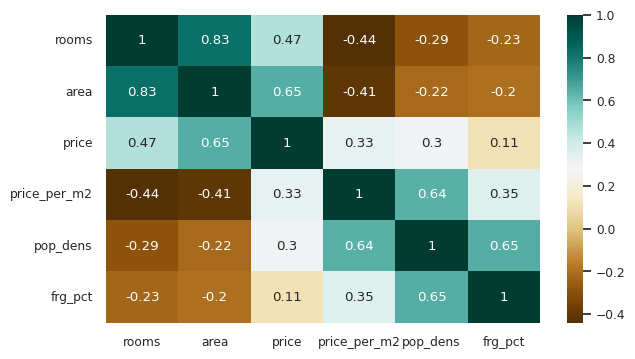

In [59]:
# Set font size for plot
sns.set(font_scale=0.8)

# Create correlation matrix as the basis for the heatmap
plt.figure(figsize=(7,4))
corr = df[['rooms', 
                     'area', 
                     'price', 
                     'price_per_m2',
                     'pop_dens',
                     'frg_pct']].corr().round(2)

# Plot heatmap
sns.heatmap(corr, 
            cmap="BrBG", 
            annot=True)

### Bubble plot (seaborn)

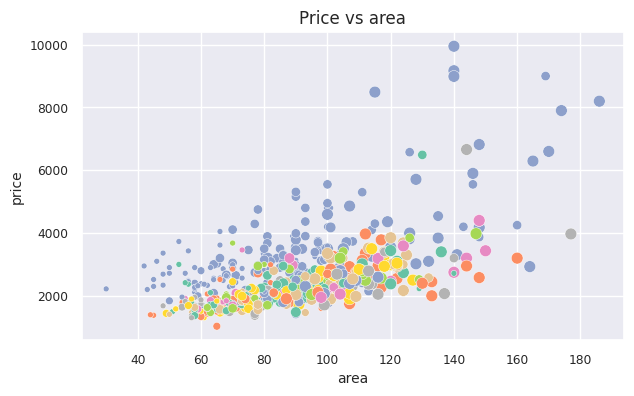

In [60]:
# Subset of df
df_sub = df.loc[(df['rooms'] >= 2.5) & (df['rooms'] <= 4.5)]

plt.figure(figsize=(7,4))
plt.ticklabel_format(style='plain')
cmap = sns.cubehelix_palette(dark=.3, light=3, as_cmap=True)

ax = sns.scatterplot(x="area", 
                     y="price",
                     size="rooms", # determines bubble size
                     hue="pop_dens",  # determines color
                     palette="Set2",
                     data=df_sub)

# Set title and axes
ax.set_title('Price vs area', fontsize = 12)
ax.set_xlabel('area', fontsize = 10)
ax.set_ylabel('price', fontsize = 10)
ax.legend([],[], frameon=False) # skip legend

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [61]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-10-26 12:38:34
Python Version: 3.11.13
-----------------------------------
